In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import sys 
sys.path.append("/cellarold/users/mpagadal/Programs/anaconda3/lib/python3.7/site-packages")

In [3]:
import statsmodels.stats.multitest as multi

In [4]:
import networkx as nx
from ndex2.nice_cx_network import NiceCXNetwork 
import ndex2.client as nc
import ndex2

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [6]:
def fdr(df,p):
    #make heritability estimate numeric
    #calculate benjamin-hochberg fdr
    probabilities = df[p].to_numpy()
    report = multi.multipletests(probabilities,
                alpha=0.05,
                method="fdr_bh",
                is_sorted=False,
            )
    discoveries = report[1]
    df["fdr"]=discoveries
    df["fdr"]=pd.to_numeric(df["fdr"])
    df["-log10(fdr)"]=-np.log10(df["fdr"])
    
    return(df)

In [7]:
def process_phewas(df, summary):
    #format phewas statistics
    df=df[~df["p"].isnull()]
    df=df[df["p"]!="p"]
    df["p"]=df["p"].astype(float)
    
    df["snp"]=df["snp"].str.replace("`","")
    df["snp"]=df["snp"].str.replace("2:31989359:GGAGTATGTTCTTGCTGAT:AGAGTATGTTCTTGCTGAT_G","2:31989359:G:A_G")
    df["description"]=df["description"].str.replace(":","")
    df["description"]=df["description"].str.replace(";","")
    
    df["minor_allele"]=df["snp"].str.split("_").str[1]
    df["snp"]=df["snp"].str.split("_").str[0]
    
    
    #format summary statistics
    summary=summary.rename(columns={"MVP_variant":"snp","group":"ancestry group"})
    summary=summary[["snp","ancestry group","rsid","A1","BETA_eur","P_eur","BETA_afr","P_afr","BETA_his","P_his","metal"]]
    
    df=pd.merge(df,summary,on="snp",how="left")
    df=df[~df["BETA_eur"].isnull()]
    
    #change beta values to be oriented to the phewas minor allele
    df["BETA_eur"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_eur"]*-1,df["BETA_eur"])
    df["BETA_afr"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_afr"]*-1,df["BETA_afr"])
    df["BETA_his"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_his"]*-1,df["BETA_his"])
    del df["A1"]
    
    df["OR"]=[np.exp(float(x)) for x in df["beta"]]
    
    return(df)

## process phewas data

In [11]:
eur_phewas=pd.read_csv("../data/phewas/compiled.eur.phewas.csv")
afr_phewas=pd.read_csv("../data/phewas/compiled.afr.phewas.csv")
his_phewas=pd.read_csv("../data/phewas/compiled.his.phewas.csv")

supptable1=pd.read_csv("../files/Supplemental Table 1.tsv",delimiter="\t")

eur_phewas=process_phewas(eur_phewas,supptable1)
afr_phewas=process_phewas(afr_phewas,supptable1)
his_phewas=process_phewas(his_phewas,supptable1)

eur_phewas=fdr(eur_phewas,"p")
afr_phewas=fdr(afr_phewas,"p")
his_phewas=fdr(his_phewas,"p")

eur_phewas_sig=eur_phewas[eur_phewas["fdr"]<.01]
afr_phewas_sig=afr_phewas[afr_phewas["fdr"]<.01]
his_phewas_sig=his_phewas[his_phewas["fdr"]<.01]

eur_phewas_sig.to_csv("../data/phewas/eur.phewas.sig.csv",index=None)
afr_phewas_sig.to_csv("../data/phewas/afr.phewas.sig.csv",index=None)
his_phewas_sig.to_csv("../data/phewas/his.phewas.sig.csv",index=None)

/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/pandas/core/ops.py:1649: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in log10
  del sys.path[0]


##### trans-ancestry snps

920 significant phewas associations in European HARE group
41 unique variants in European HARE group
45 significant phewas associations in African HARE group
16 unique variants in African HARE group
56 significant phewas associations in Hispanic HARE group
14 unique variants in Hispanic HARE group


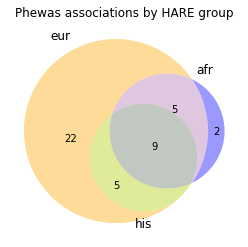

In [14]:
metal_snps=supptable1[supptable1["metal"]=="yes"]["MVP_variant"].tolist()
metal_snps=[x.rsplit(":",2)[0]+":"+x.split(":")[3]+":"+x.split(":")[2] for x in metal_snps]+metal_snps

eur_phewas_trans=eur_phewas[eur_phewas["snp"].isin(metal_snps)]
afr_phewas_trans=afr_phewas[afr_phewas["snp"].isin(metal_snps)]
his_phewas_trans=his_phewas[his_phewas["snp"].isin(metal_snps)]

fdr_thresh=0.01
eur_phewas_sig=eur_phewas_trans[eur_phewas_trans["fdr"]<fdr_thresh]
print("{} significant phewas associations in European HARE group".format(len(eur_phewas_sig)))
print("{} unique variants in European HARE group".format(len(eur_phewas_sig["snp"].unique())))

afr_phewas_sig=afr_phewas_trans[afr_phewas_trans["fdr"]<fdr_thresh]
print("{} significant phewas associations in African HARE group".format(len(afr_phewas_sig)))
print("{} unique variants in African HARE group".format(len(afr_phewas_sig["snp"].unique())))

his_phewas_sig=his_phewas_trans[his_phewas_trans["fdr"]<fdr_thresh]
print("{} significant phewas associations in Hispanic HARE group".format(len(his_phewas_sig)))
print("{} unique variants in Hispanic HARE group".format(len(his_phewas_sig["snp"].unique())))

plt.title("Phewas associations by HARE group")
venn3([set(eur_phewas_sig["snp"].unique()),set(afr_phewas_sig["snp"].unique()),set(his_phewas_sig["snp"].unique())],
      set_labels=("eur","afr","his"), set_colors=["orange","blue","green"])
plt.savefig("../plots/phewas/hare.phewas.snps.png")



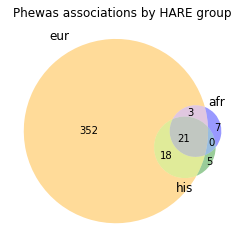

In [15]:
afr_unique_snps=[x for x in afr_phewas_sig["snp"].unique() if x not in eur_phewas_sig["snp"].unique().tolist()+his_phewas_sig["snp"].unique().tolist()]
his_unique_snps=[x for x in his_phewas_sig["snp"].unique() if x not in eur_phewas_sig["snp"].unique().tolist()+afr_phewas_sig["snp"].unique().tolist()]

plt.title("Phewas associations by HARE group")
venn3([set(eur_phewas_sig["description"].unique()),set(afr_phewas_sig["description"].unique()),set(his_phewas_sig["description"].unique())],
      set_labels=("eur","afr","his"), set_colors=["orange","blue","green"])
plt.savefig("../plots/hare.phewas.png")

##### export for gephi

In [16]:
def make_gephi(df,out):
    
    nodes=pd.DataFrame({"Id":df["snp"].unique().tolist()+df["description"].unique().tolist()})
    nodes["type"]=np.where(nodes["Id"].str.contains(":"),"SNP","PHECODE")
    
    mp_phewas=dict(zip(df["description"],df["group"]))
    nodes["type"]=nodes["Id"].map(mp_phewas)
    nodes["type"]=nodes["type"].fillna("SNP")
    
    nodes.to_csv(out+".nodes.csv",index=None,sep=";")
    
    edges=df[["snp","description"]].copy()
    edges.columns=["Source","Target"]
    edges.to_csv(out+".edges.csv",index=None,sep=";")

eur_nodes=make_gephi(eur_phewas_trans[eur_phewas_trans["fdr"]<.01],"../data/phewas/gephi/eur")
afr_nodes=make_gephi(afr_phewas_trans[afr_phewas_trans["fdr"]<.01],"../data/phewas/gephi/afr")
his_nodes=make_gephi(his_phewas_trans[his_phewas_trans["fdr"]<.01],"../data/phewas/gephi/his")

##### ancestry-specific associations

In [17]:
eur_phewas_ancestry=eur_phewas[(eur_phewas["metal"]=="no")&(eur_phewas["fdr"]<.01)]
afr_phewas_ancestry=afr_phewas[(afr_phewas["metal"]=="no")&(afr_phewas["fdr"]<.01)]
his_phewas_ancestry=his_phewas[(his_phewas["metal"]=="no")&(his_phewas["fdr"]<.01)]

afr_phewas_ancestry_hits=afr_phewas_ancestry[afr_phewas_ancestry["ancestry group"]=="afr"]
his_phewas_ancestry_hits=his_phewas_ancestry[his_phewas_ancestry["ancestry group"]=="his"]

## process labwas data

In [18]:
def process_labwas(df,summary):
    df["pheno"]=df["file"].str.split(".dose.").str[1]
    df["pheno"]=df["pheno"].str.split(".glm.linear").str[0]
    df["ID"]=df["ID"].str.replace("2:31989359:GGAGTATGTTCTTGCTGAT:AGAGTATGTTCTTGCTGAT","2:31989359:G:A")
        
    df["minor_allele"]=df["A1"]
    del df["A1"]

    #format summary statistics
    summary=summary.rename(columns={"MVP_variant":"ID","group":"ancestry group"})
    summary=summary[["ID","ancestry group","rsid","A1","BETA_eur","P_eur","BETA_afr","P_afr","BETA_his","P_his","metal"]]
    
    df=pd.merge(df,summary,on="ID",how="left")
    
    #change beta values to be oriented to the phewas minor allele
    df["BETA_eur"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_eur"]*-1,df["BETA_eur"])
    df["BETA_afr"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_afr"]*-1,df["BETA_afr"])
    df["BETA_his"]=np.where(df["minor_allele"]!=df["A1"],df["BETA_his"]*-1,df["BETA_his"])
    return(df)

In [35]:
eur_labwas=pd.read_csv("../data/labwas/compiled.eur.labwas.mean.results.csv")
afr_labwas=pd.read_csv("../data/labwas/compiled.afr.labwas.mean.results.csv")
his_labwas=pd.read_csv("../data/labwas/compiled.his.labwas.mean.results.csv")

eur_labwas=process_labwas(eur_labwas,supptable1)
afr_labwas=process_labwas(afr_labwas,supptable1)
his_labwas=process_labwas(his_labwas,supptable1)

eur_labwas=eur_labwas[~eur_labwas["P"].isnull()]
afr_labwas=afr_labwas[~afr_labwas["P"].isnull()]
his_labwas=his_labwas[~his_labwas["P"].isnull()]

eur_labwas=fdr(eur_labwas,"P")
afr_labwas=fdr(afr_labwas,"P")
his_labwas=fdr(his_labwas,"P")

eur_labwas[eur_labwas["fdr"]<.01].to_csv("../data/labwas/eur.labwas.sig.csv",index=None)
afr_labwas[afr_labwas["fdr"]<.01].to_csv("../data/labwas/afr.labwas.sig.csv",index=None)
his_labwas[his_labwas["fdr"]<.01].to_csv("../data/labwas/his.labwas.sig.csv",index=None)

eur_labwas=eur_labwas[eur_labwas["ID"].isin(supptable1["MVP_variant"].tolist())]
afr_labwas=afr_labwas[afr_labwas["ID"].isin(supptable1["MVP_variant"].tolist())]
his_labwas=his_labwas[his_labwas["ID"].isin(supptable1["MVP_variant"].tolist())]

/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in log10
  del sys.path[0]


##### trans-ancestry variants

668 significant phewas associations in European HARE group
42 unique variants in European HARE group
150 significant phewas associations in African HARE group
27 unique variants in African HARE group
44 significant phewas associations in Hispanic HARE group
19 unique variants in Hispanic HARE group


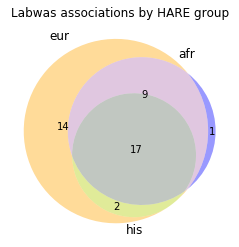

In [40]:
eur_labwas_trans=eur_labwas[(eur_labwas["metal"]=="yes")&(eur_labwas["fdr"]<.01)]
afr_labwas_trans=afr_labwas[(afr_labwas["metal"]=="yes")&(afr_labwas["fdr"]<.01)]
his_labwas_trans=his_labwas[(his_labwas["metal"]=="yes")&(his_labwas["fdr"]<.01)]

eur_labwas_sig=eur_labwas_trans[eur_labwas_trans["fdr"]<.01]
print("{} significant phewas associations in European HARE group".format(len(eur_labwas_sig)))
print("{} unique variants in European HARE group".format(len(eur_labwas_sig["ID"].unique())))

afr_labwas_sig=afr_labwas_trans[afr_labwas_trans["fdr"]<.01]
print("{} significant phewas associations in African HARE group".format(len(afr_labwas_sig)))
print("{} unique variants in African HARE group".format(len(afr_labwas_sig["ID"].unique())))

his_labwas_sig=his_labwas_trans[his_labwas_trans["fdr"]<.01]
print("{} significant phewas associations in Hispanic HARE group".format(len(his_labwas_sig)))
print("{} unique variants in Hispanic HARE group".format(len(his_labwas_sig["ID"].unique())))

plt.title("Labwas associations by HARE group")
venn3([set(eur_labwas_sig["ID"].unique()),set(afr_labwas_sig["ID"].unique()),set(his_labwas_sig["ID"].unique())],
      set_labels=("eur","afr","his"), set_colors=["orange","blue","green"])
plt.savefig("../plots/labwas/hare.labwas.snps.png")

In [41]:
shared_labwas=[x for x in eur_labwas_sig["pheno"].unique() if x in afr_labwas_sig["pheno"].tolist()]
shared_labwas=[x for x in shared_labwas if x in his_labwas_sig["pheno"].tolist()]

##### ancestry-specific associations

In [42]:
eur_labwas_ancestry=eur_labwas[(eur_labwas["metal"]=="no")&(eur_labwas["fdr"]<.01)]
afr_labwas_ancestry=afr_labwas[(afr_labwas["metal"]=="no")&(afr_labwas["fdr"]<.01)]
his_labwas_ancestry=his_labwas[(his_labwas["metal"]=="no")&(his_labwas["fdr"]<.01)]

##### make genome decoration dataframe

In [43]:
def make_genome_decoration(df,col_name):
    df["chr"]=df[col_name].str.split(":").str[0]
    df["bp1"]=df[col_name].str.split(":").str[1]
    df["bp1"]=df["bp1"].astype(int)
    df["bp2"]=df["bp1"]+1
    dec=df[["chr","bp1","bp2"]]
    dec=dec.drop_duplicates()
    return(dec)

In [44]:
make_genome_decoration(eur_phewas_sig,"snp").to_csv("../data/phewas/eur.phewas.bed",header=None,index=None,sep="\t")
make_genome_decoration(afr_phewas_sig,"snp").to_csv("../data/phewas/afr.phewas.bed",header=None,index=None,sep="\t")
make_genome_decoration(his_phewas_sig,"snp").to_csv("../data/phewas/his.phewas.bed",header=None,index=None,sep="\t")

/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to 

In [45]:
make_genome_decoration(eur_labwas_sig,"ID").to_csv("../data/phewas/eur.labwas.bed",header=None,index=None,sep="\t")
make_genome_decoration(afr_labwas_sig,"ID").to_csv("../data/phewas/afr.labwas.bed",header=None,index=None,sep="\t")
make_genome_decoration(his_labwas_sig,"ID").to_csv("../data/phewas/his.labwas.bed",header=None,index=None,sep="\t")

##### plot highlighted snps

In [62]:
eur_stats=pd.read_csv("../data/summarystats/significant/compiled.eur.all.variant.glm.linear",delimiter="\t")
afr_stats=pd.read_csv("../data/summarystats/significant/compiled.afr.all.variant.glm.linear",delimiter="\t")
his_stats=pd.read_csv("../data/summarystats/significant/compiled.his.all.variant.glm.linear",delimiter="\t")

##### rs190119169

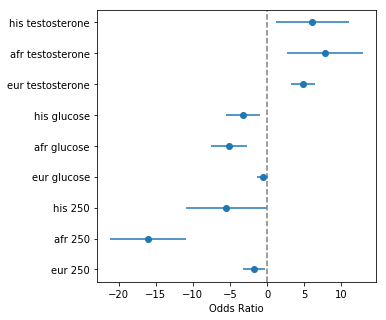

In [63]:
value=[]
beta=[]
se=[]
a1=[]

value.append("eur 250")
beta.append(eur_phewas[(eur_phewas["snp"]=="X:67045153:T:C")&(eur_phewas["phenotype"]==250.00)]["beta"].tolist()[0])
se.append(eur_phewas[(eur_phewas["snp"]=="X:67045153:T:C")&(eur_phewas["phenotype"]==250.00)]["SE"].tolist()[0])
a1.append(eur_phewas[(eur_phewas["snp"]=="X:67045153:T:C")&(eur_phewas["phenotype"]==250.00)]["minor_allele"].tolist()[0])

value.append("afr 250")
beta.append(afr_phewas[(afr_phewas["snp"]=="X:67045153:T:C")&(afr_phewas["phenotype"]==250.00)]["beta"].tolist()[0])
se.append(afr_phewas[(afr_phewas["snp"]=="X:67045153:T:C")&(afr_phewas["phenotype"]==250.00)]["SE"].tolist()[0])
a1.append(afr_phewas[(afr_phewas["snp"]=="X:67045153:T:C")&(afr_phewas["phenotype"]==250.00)]["minor_allele"].tolist()[0])

value.append("his 250")
beta.append(his_phewas[(his_phewas["snp"]=="X:67045153:T:C")&(his_phewas["phenotype"]==250.00)]["beta"].tolist()[0])
se.append(his_phewas[(his_phewas["snp"]=="X:67045153:T:C")&(his_phewas["phenotype"]==250.00)]["SE"].tolist()[0])
a1.append(his_phewas[(his_phewas["snp"]=="X:67045153:T:C")&(his_phewas["phenotype"]==250.00)]["minor_allele"].tolist()[0])

value.append("eur glucose")
beta.append(eur_labwas[(eur_labwas["ID"]=="X:67045153:T:C")&(eur_labwas["pheno"]=="glucose_mean")]["BETA"].tolist()[0])
se.append(eur_labwas[(eur_labwas["ID"]=="X:67045153:T:C")&(eur_labwas["pheno"]=="glucose_mean")]["SE"].tolist()[0])
a1.append(eur_labwas[(eur_labwas["ID"]=="X:67045153:T:C")&(eur_labwas["pheno"]=="glucose_mean")]["minor_allele"].tolist()[0])

value.append("afr glucose")
beta.append(afr_labwas[(afr_labwas["ID"]=="X:67045153:T:C")&(afr_labwas["pheno"]=="glucose_mean")]["BETA"].tolist()[0])
se.append(afr_labwas[(afr_labwas["ID"]=="X:67045153:T:C")&(afr_labwas["pheno"]=="glucose_mean")]["SE"].tolist()[0])
a1.append(afr_labwas[(afr_labwas["ID"]=="X:67045153:T:C")&(afr_labwas["pheno"]=="glucose_mean")]["minor_allele"].tolist()[0])

value.append("his glucose")
beta.append(his_labwas[(his_labwas["ID"]=="X:67045153:T:C")&(his_labwas["pheno"]=="glucose_mean")]["BETA"].tolist()[0])
se.append(his_labwas[(his_labwas["ID"]=="X:67045153:T:C")&(his_labwas["pheno"]=="glucose_mean")]["SE"].tolist()[0])
a1.append(his_labwas[(his_labwas["ID"]=="X:67045153:T:C")&(his_labwas["pheno"]=="glucose_mean")]["minor_allele"].tolist()[0])

value.append("eur testosterone")
beta.append(eur_stats[eur_stats["ID"]=="X:67045153:T:C"]["BETA"].tolist()[0])
se.append(eur_stats[eur_stats["ID"]=="X:67045153:T:C"]["SE"].tolist()[0])
a1.append(eur_stats[eur_stats["ID"]=="X:67045153:T:C"]["A1"].tolist()[0])

value.append("afr testosterone")
beta.append(afr_stats[afr_stats["ID"]=="X:67045153:T:C"]["BETA"].tolist()[0])
se.append(afr_stats[afr_stats["ID"]=="X:67045153:T:C"]["SE"].tolist()[0])
a1.append(afr_stats[afr_stats["ID"]=="X:67045153:T:C"]["A1"].tolist()[0])

value.append("his testosterone")
beta.append(his_stats[his_stats["ID"]=="X:67045153:T:C"]["BETA"].tolist()[0])
se.append(his_stats[his_stats["ID"]=="X:67045153:T:C"]["SE"].tolist()[0])
a1.append(his_stats[his_stats["ID"]=="X:67045153:T:C"]["A1"].tolist()[0])

df_plot=pd.DataFrame({"value":value,"beta":beta,"se":se,"a1":a1})
df_plot["beta"]=np.where(df_plot["a1"]!="C",df_plot["beta"]*-1,df_plot["beta"])
df_plot["se"]=df_plot["se"]*2

f=plt.figure(figsize=(5,5))
plt.errorbar(df_plot["beta"],df_plot["value"],xerr=df_plot["se"],fmt="o")
plt.axvline(0,linestyle="--",color="gray")
plt.xlabel("Odds Ratio")
plt.savefig("../plots/phewas/rs190119169.pdf")

##### rs4827451

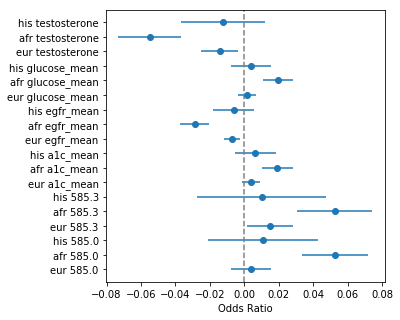

In [64]:
value=[]
beta=[]
se=[]
a1=[]

### PheWAS
snp="X:65317736:G:A"
pheno=585.00

value.append("eur "+str(pheno))
beta.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

value.append("afr "+str(pheno))
beta.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

value.append("his "+str(pheno))
beta.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

snp="X:65317736:G:A"
pheno=585.30

value.append("eur "+str(pheno))
beta.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(eur_phewas[(eur_phewas["snp"]==snp)&(eur_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

value.append("afr "+str(pheno))
beta.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(afr_phewas[(afr_phewas["snp"]==snp)&(afr_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

value.append("his "+str(pheno))
beta.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["beta"].tolist()[0])
se.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["SE"].tolist()[0])
a1.append(his_phewas[(his_phewas["snp"]==snp)&(his_phewas["phenotype"]==pheno)]["minor_allele"].tolist()[0])

### LabWAS

snp="X:65317736:G:A"
pheno="a1c_mean"

value.append("eur "+pheno)
beta.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("afr "+pheno)
beta.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("his "+pheno)
beta.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

snp="X:65317736:G:A"
pheno="egfr_mean"

value.append("eur "+pheno)
beta.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("afr "+pheno)
beta.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("his "+pheno)
beta.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

snp="X:65317736:G:A"
pheno="glucose_mean"

value.append("eur "+pheno)
beta.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(eur_labwas[(eur_labwas["ID"]==snp)&(eur_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("afr "+pheno)
beta.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(afr_labwas[(afr_labwas["ID"]==snp)&(afr_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

value.append("his "+pheno)
beta.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["BETA"].tolist()[0])
se.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["SE"].tolist()[0])
a1.append(his_labwas[(his_labwas["ID"]==snp)&(his_labwas["pheno"]==pheno)]["minor_allele"].tolist()[0])

### Testosterone

value.append("eur testosterone")
beta.append(eur_stats[eur_stats["ID"]==snp]["BETA"].tolist()[0])
se.append(eur_stats[eur_stats["ID"]==snp]["SE"].tolist()[0])
a1.append(eur_stats[eur_stats["ID"]==snp]["A1"].tolist()[0])

value.append("afr testosterone")
beta.append(afr_stats[afr_stats["ID"]==snp]["BETA"].tolist()[0])
se.append(afr_stats[afr_stats["ID"]==snp]["SE"].tolist()[0])
a1.append(afr_stats[afr_stats["ID"]==snp]["A1"].tolist()[0])

value.append("his testosterone")
beta.append(his_stats[his_stats["ID"]==snp]["BETA"].tolist()[0])
se.append(his_stats[his_stats["ID"]==snp]["SE"].tolist()[0])
a1.append(his_stats[his_stats["ID"]==snp]["A1"].tolist()[0])

df_plot=pd.DataFrame({"value":value,"beta":beta,"se":se,"a1":a1})
df_plot["beta"]=np.where(df_plot["a1"]!="G",df_plot["beta"]*-1,df_plot["beta"])
df_plot["se"]=df_plot["se"]*2

f=plt.figure(figsize=(5,5))
plt.errorbar(df_plot["beta"],df_plot["value"],xerr=df_plot["se"],fmt="o")
plt.axvline(0,linestyle="--",color="gray")
plt.xlabel("Odds Ratio")
plt.savefig("../plots/phewas/rs4827451.pdf")